<a href="https://colab.research.google.com/github/lcuenca1/Data201/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 - Logistic Regression

In [1]:
import pandas as pd
housing = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")
housing.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily


### 1. Creating a Binary Outcome




In [3]:
median_price = housing['price'].median()
housing['high_price'] = (housing['price'] > median_price).astype(int)

housing[['price','high_price']].head()

,price,high_price
0,145143.0,0
1,152251.0,0
2,148251.0,0
3,177711.0,0
4,155269.0,0


### Part A - Logistic Regression for Inference

In [5]:
import statsmodels.formula.api as smf
import numpy as np

In [8]:
import statsmodels.formula.api as smf
import numpy as np

model = smf.logit(
    "high_price ~ size + bedrooms + C(neighborhood)",
    data=housing).fit()

print(model.summary())

results_table = pd.DataFrame({
    "Coefficient": model.params,
    "Odds Ratio": np.exp(model.params),
    "P-value": model.pvalues})

print(results_table)

Optimization terminated successfully.
         Current function value: 0.684990
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             high_price   No. Observations:                  524
Model:                          Logit   Df Residuals:                      517
Method:                           MLE   Df Model:                            6
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                 0.01177
Time:                        16:12:37   Log-Likelihood:                -358.93
converged:                       True   LL-Null:                       -363.21
Covariance Type:            nonrobust   LLR p-value:                    0.2006
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.3796      0.289      1.311      0.

The variable 'size" looks like it's the only statistically significant because its p-value (0.036) is below 0.05. This suggest that the house size is associated with the increasing of price.  
Among the neighborhoods, Waterfront has the highest odds ratio (1.51), indicating higher oddsof expensive homes compare to the other neighborhoods.However, it's p value is higher than alpha, making it statistically irrelevant.

### Part B - Bedroom Variable

For every additional bedroom, the odds of a house being expensive increase by about 26%. In other words, houses with more bedrooms are more likely to cost over the median price.. So the number of bedrooms is positively associated with house prices.

### Part C - Prediction Workflow

1. Train/ Text split

In [11]:
from sklearn.model_selection import train_test_split

X = housing[['size','bedrooms']].fillna(housing[['size','bedrooms']].median())
y = housing['high_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 480
Testing set size: 120


2. Fit Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("First 10 predictions:", y_pred[:10])

First 10 predictions: [1 0 1 1 0 1 1 1 1 1]


3. Evaluate the model

Accuracy: 0.5833333333333334
ROC–AUC: 0.6395154553049289


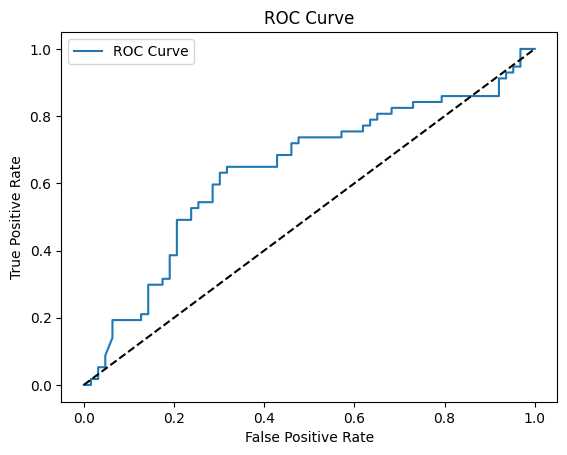

In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC–AUC:", roc_auc_score(y_test, y_pred_proba))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0,1],[0,1],'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Part D - Model Understanding

Accuracy vs AUC  

ROC–AUC is often better than accuracy because it shows how well the model can tell expensive and cheap houses apart, no matter where you set the cutoff. Accuracy just looks at one cutoff and can be misleading, especially if one group is much bigger than the other.  

Inference vs Prediction  
For policy analysis, we would use the inference approach because it helps us understand which factors (like size or bedrooms) affect house prices. This is important when we want to explain why prices go up or down. For prediction, like guessing if a house is expensive or not, we use the prediction approach (like the logistic regression we trained) because it focuses on making the best guesses, even if it doesn’t explain everything clearly.

Part E - Explore the Dataset

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

a) Histogram

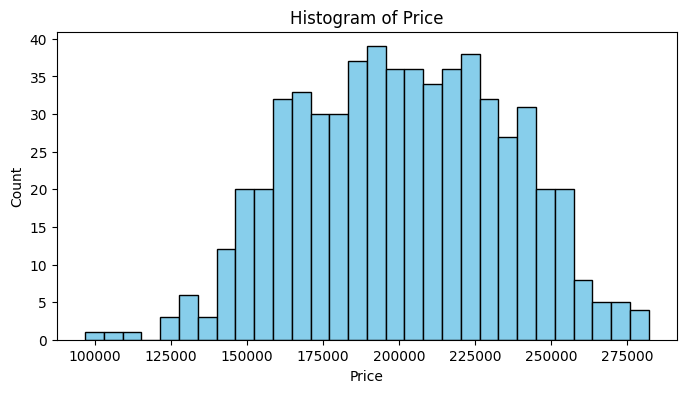

In [15]:
plt.figure(figsize=(8,4))
plt.hist(housing['price'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Price')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

b) Scatterplot: Size vs Price

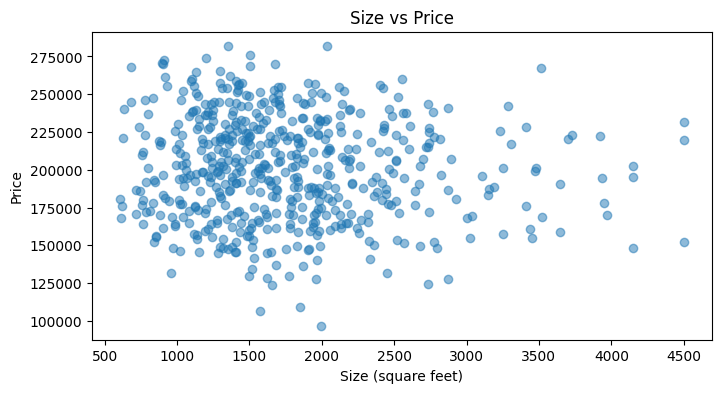

In [16]:
plt.figure(figsize=(8,4))
plt.scatter(housing['size'], housing['price'], alpha=0.5)
plt.title('Size vs Price')
plt.xlabel('Size (square feet)')
plt.ylabel('Price')
plt.show()

c) Boxplot

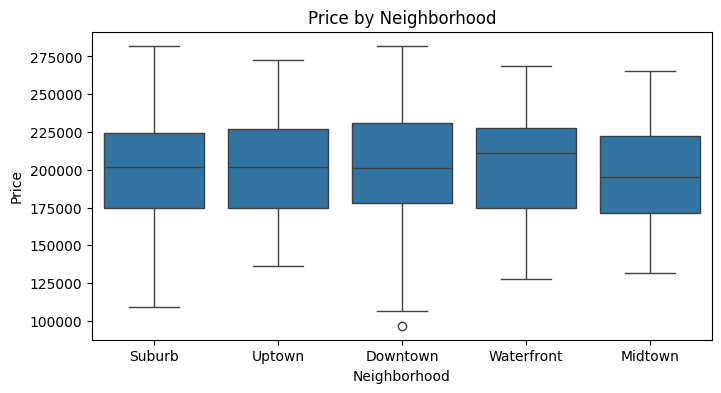

In [17]:
plt.figure(figsize=(8,4))
sns.boxplot(x='neighborhood', y='price', data=housing)
plt.title('Price by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Price')
plt.show()

The histogram shows that most houses are priced between $150,000 and $250,000, with fewer very cheap or very expensive homes. The boxplot reveals that while most neighborhoods have similar price ranges, Waterfront houses tend to be a bit more expensive on average, and Downtown has more variation with some unusually low-priced houses. The scatterplot shows that larger houses generally cost more, but size alone doesn’t explain all the price differences. Together, these plots suggest that both the size of the house and its neighborhood play important roles in determining price.